In [80]:
import numpy as np
import matplotlib.pyplot as plt
import skyproj, healpy as hp, h5py, fitsio
from scipy import stats

import os
if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2023/bin/x86_64-linux"

plt.rcParams["axes.linewidth"]  = 1.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=17)

if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2022-el8-x86_64/bin/x86_64-linux/"


COLORS = ["f07167","219ebc","ffba0a","c767ac","59a270"]
COLORS = ['#' + c if c[0] != '#' else c for c in COLORS ]

from cycler import cycler

# Update the default prop_cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=COLORS)


from matplotlib.colors import LinearSegmentedColormap, ListedColormap

C0 = LinearSegmentedColormap.from_list(None, ['white', 'C0']); #C0.set_bad(color = 'white')
C1 = LinearSegmentedColormap.from_list(None, ['white', 'C1']); #C1.set_bad(color = 'white')
C2 = LinearSegmentedColormap.from_list(None, ['white', 'C2']); #C2.set_bad(color = 'white')
C3 = LinearSegmentedColormap.from_list(None, ['white', 'C3']); #C3.set_bad(color = 'white')
C4 = LinearSegmentedColormap.from_list(None, ['white', 'C4']); #C4.set_bad(color = 'white')

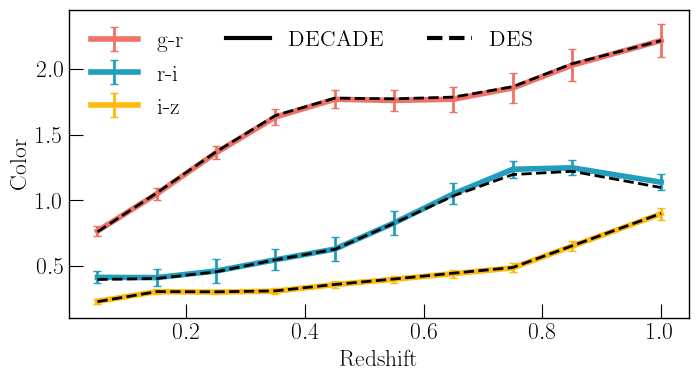

In [84]:
decade = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADE_20250820/Files/my_decade_zspec_redgals_model.fit')
des    = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DES_20250828/Files/my_decade_zspec_redgals_model.fit')

plt.figure(figsize = (8, 4))
plt.errorbar(decade['nodes'][0], decade['meancol'][0][:, 0], yerr = decade['meancol_scatter'][0][:, 0], lw = 4, elinewidth = 2, label = 'g-r', capsize = 3)
plt.errorbar(decade['nodes'][0], decade['meancol'][0][:, 1], yerr = decade['meancol_scatter'][0][:, 1], lw = 4, elinewidth = 2, label = 'r-i', capsize = 3)
plt.errorbar(decade['nodes'][0], decade['meancol'][0][:, 2], yerr = decade['meancol_scatter'][0][:, 2], lw = 4, elinewidth = 2, label = 'i-z', capsize = 3)


plt.errorbar(des['nodes'][0], des['meancol'][0][:, 0], ls = '--', color = 'k', lw = 2)
plt.errorbar(des['nodes'][0], des['meancol'][0][:, 1], ls = '--', color = 'k', lw = 2)
plt.errorbar(des['nodes'][0], des['meancol'][0][:, 2], ls = '--', color = 'k', lw = 2)

leg = plt.legend(ncol = 1)
plt.gca().add_artist(leg)

plt.xlabel('Redshift', size = 17)
plt.ylabel('Color',    size = 17)

plt.legend([plt.plot([], [], color = 'k', lw = 3, ls = l)[0] for l in ['-', '--']],
           ['DECADE', 'DES'], fontsize = 16, loc = 'upper center', ncol = 2)

plt.savefig('./RedSequenceModel.pdf', dpi = 300)
plt.show()